# System Engineering Lab — vaste groepen afleiden uit individuele wifi-connecties

Deze versie gebruikt rechtstreeks:

- `DEP2.dbo.FactLecture`, `DimDate`, `DimTime`, `DimClass`, `DimSubgroup`
- `DEP2_staging.dbo.FactWifiConnection`
- `DEP2_staging.dbo.DimUser`
- `DEP2_staging.dbo.BridgeUserSubgroup`

Werkwijze:

1. twee opeenvolgende roosterblokken worden samengevoegd tot één sessie van ongeveer vier uur;
2. wifi-connecties worden op basis van datum en tijd aan die sessies gekoppeld;
3. meerdere connecties van dezelfde gebruiker binnen één sessie tellen maar één keer;
4. de eerste geobserveerde week wordt optioneel niet gebruikt voor de groepsindeling;
5. iedere gebruiker wordt toegewezen aan het vaste sessietype waarin die het vaakst werd gezien;
6. het aantal toegewezen gebruikers wordt de noemer voor dat sessietype;
7. de aanwezigheid per sessie wordt opnieuw berekend.

Er is geen access-pointinformatie. De notebook volgt daarom de projectaanname dat een student die tijdens zijn geroosterde les met wifi verbonden is, als aanwezig mag worden beschouwd.


In [1]:
import pandas as pd
import numpy as np
import sqlalchemy as sa
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 300)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")


## 1. Instellingen

In [2]:
server = "localhost\\MSSQLSERVER2019"
main_database = "DEP2"
staging_database = "DEP2_staging"
driver = "ODBC Driver 17 for SQL Server"

COURSE_NAME = "System Engineering Lab"
PROGRAM_FILTER = "PBA-TIN%"
SEMESTER_NUMBER = 2
START_DATE = "2026-02-01"
END_DATE = "2026-06-30"

MAX_BREAK_MINUTES = 30
MIN_SESSION_DURATION_MINUTES = 210
MAX_SESSION_DURATION_MINUTES = 300

EXCLUDE_FIRST_OBSERVED_WEEK_FOR_ASSIGNMENT = True
MIN_OBSERVED_SESSIONS_PER_STUDENT = 2
TIE_POLICY = "unassigned"  # of "latest"

engine = sa.create_engine(
    f"mssql+pyodbc://@{server}/{main_database}"
    f"?driver={driver}&trusted_connection=yes&TrustServerCertificate=yes"
)


## 2. Roosterdata ophalen

In [3]:
schedule_query = f'''
SELECT
    fl.LectureID,
    fl.DateKey,
    fl.FromTimeKey,
    fl.UntilTimeKey,
    fl.SubgroupKey,
    d.FullDate,
    d.NumberSemester,
    tf.Hour AS FromHour,
    tf.Minutes AS FromMinutes,
    tf.Seconds AS FromSeconds,
    tu.Hour AS UntilHour,
    tu.Minutes AS UntilMinutes,
    tu.Seconds AS UntilSeconds,
    c.ClassName,
    sg.SubgroupCode,
    sg.ProgramName
FROM [{main_database}].dbo.FactLecture fl
JOIN [{main_database}].dbo.DimDate d
    ON fl.DateKey = d.DateKey
JOIN [{main_database}].dbo.DimTime tf
    ON fl.FromTimeKey = tf.TimeKey
JOIN [{main_database}].dbo.DimTime tu
    ON fl.UntilTimeKey = tu.TimeKey
JOIN [{main_database}].dbo.DimClass c
    ON fl.ClassKey = c.ClassKey
JOIN [{main_database}].dbo.DimSubgroup sg
    ON fl.SubgroupKey = sg.SubgroupKey
WHERE sg.ProgramName LIKE ?
  AND c.ClassName = ?
  AND d.NumberSemester = ?
  AND d.FullDate BETWEEN ? AND ?
ORDER BY d.FullDate, tf.Hour, tf.Minutes, sg.SubgroupCode;
'''

schedule_raw = pd.read_sql(
    schedule_query,
    engine,
    params=(
        PROGRAM_FILTER,
        COURSE_NAME,
        SEMESTER_NUMBER,
        START_DATE,
        END_DATE,
    ),
)

schedule_raw["FullDate"] = pd.to_datetime(schedule_raw["FullDate"])

print(f"Factrijen: {len(schedule_raw):,}")
print(f"Unieke LectureID's: {schedule_raw['LectureID'].nunique():,}")
print(f"Lesdagen: {schedule_raw['FullDate'].nunique():,}")
print(f"Subgroepen: {schedule_raw['SubgroupKey'].nunique():,}")

schedule_raw.head(20)


Factrijen: 539
Unieke LectureID's: 77
Lesdagen: 36
Subgroepen: 8


,LectureID,DateKey,FromTimeKey,UntilTimeKey,SubgroupKey,FullDate,NumberSemester,FromHour,FromMinutes,FromSeconds,UntilHour,UntilMinutes,UntilSeconds,ClassName,SubgroupCode,ProgramName
0,424591,20260211,81500,101500,5938937,2026-02-11,2,8,15,0,10,15,0,System Engineering Lab,PBA-TIN-TI/1A,PBA-TIN-TI
1,424591,20260211,81500,101500,5829023,2026-02-11,2,8,15,0,10,15,0,System Engineering Lab,PBA-TIN-TI/1B,PBA-TIN-TI
2,424591,20260211,81500,101500,5829227,2026-02-11,2,8,15,0,10,15,0,System Engineering Lab,PBA-TIN-TI/1C,PBA-TIN-TI
3,424591,20260211,81500,101500,5997470,2026-02-11,2,8,15,0,10,15,0,System Engineering Lab,PBA-TIN-TI/1D,PBA-TIN-TI
4,424591,20260211,81500,101500,5997674,2026-02-11,2,8,15,0,10,15,0,System Engineering Lab,PBA-TIN-TI/1E,PBA-TIN-TI
5,424591,20260211,81500,101500,5997878,2026-02-11,2,8,15,0,10,15,0,System Engineering Lab,PBA-TIN-TI/1F,PBA-TIN-TI
6,424591,20260211,81500,101500,5879360,2026-02-11,2,8,15,0,10,15,0,System Engineering Lab,PBA-TIN-TI/1G,PBA-TIN-TI
7,424606,20260211,103000,123000,5938937,2026-02-11,2,10,30,0,12,30,0,System Engineering Lab,PBA-TIN-TI/1A,PBA-TIN-TI
8,424606,20260211,103000,123000,5829023,2026-02-11,2,10,30,0,12,30,0,System Engineering Lab,PBA-TIN-TI/1B,PBA-TIN-TI
9,424606,20260211,103000,123000,5829227,2026-02-11,2,10,30,0,12,30,0,System Engineering Lab,PBA-TIN-TI/1C,PBA-TIN-TI


## 3. Exacte tijden opbouwen

In [4]:
schedule_raw["StartDateTime"] = (
    schedule_raw["FullDate"]
    + pd.to_timedelta(schedule_raw["FromHour"], unit="h")
    + pd.to_timedelta(schedule_raw["FromMinutes"], unit="m")
    + pd.to_timedelta(schedule_raw["FromSeconds"], unit="s")
)

schedule_raw["EndDateTime"] = (
    schedule_raw["FullDate"]
    + pd.to_timedelta(schedule_raw["UntilHour"], unit="h")
    + pd.to_timedelta(schedule_raw["UntilMinutes"], unit="m")
    + pd.to_timedelta(schedule_raw["UntilSeconds"], unit="s")
)

time_blocks = (
    schedule_raw[["FullDate", "StartDateTime", "EndDateTime"]]
    .drop_duplicates()
    .sort_values(["FullDate", "StartDateTime", "EndDateTime"])
    .reset_index(drop=True)
)

time_blocks.head(20)


,FullDate,StartDateTime,EndDateTime
0,2026-02-11,2026-02-11 08:15:00,2026-02-11 10:15:00
1,2026-02-11,2026-02-11 10:30:00,2026-02-11 12:30:00
2,2026-02-12,2026-02-12 13:30:00,2026-02-12 15:30:00
3,2026-02-12,2026-02-12 15:45:00,2026-02-12 17:45:00
4,2026-02-13,2026-02-13 08:15:00,2026-02-13 10:15:00
5,2026-02-13,2026-02-13 10:30:00,2026-02-13 12:30:00
6,2026-02-18,2026-02-18 08:15:00,2026-02-18 10:15:00
7,2026-02-18,2026-02-18 10:30:00,2026-02-18 12:30:00
8,2026-02-19,2026-02-19 13:30:00,2026-02-19 15:30:00
9,2026-02-19,2026-02-19 15:45:00,2026-02-19 17:45:00


## 4. Opeenvolgende blokken samenvoegen

In [5]:
def assign_session_ids(day_blocks):
    day_blocks = day_blocks.sort_values(
        ["StartDateTime", "EndDateTime"]
    ).copy()

    session_number = 0
    current_start = None
    current_end = None
    assigned = []

    for row in day_blocks.itertuples(index=False):
        if current_start is None:
            session_number += 1
            current_start = row.StartDateTime
            current_end = row.EndDateTime
        else:
            gap_minutes = (
                row.StartDateTime - current_end
            ).total_seconds() / 60

            proposed_end = max(current_end, row.EndDateTime)
            proposed_duration = (
                proposed_end - current_start
            ).total_seconds() / 60

            if (
                gap_minutes <= MAX_BREAK_MINUTES
                and proposed_duration <= MAX_SESSION_DURATION_MINUTES
            ):
                current_end = proposed_end
            else:
                session_number += 1
                current_start = row.StartDateTime
                current_end = row.EndDateTime

        assigned.append(session_number)

    day_blocks["SessionNumberOnDay"] = assigned
    return day_blocks


processed_days = []

for _, day_blocks in time_blocks.groupby("FullDate", sort=True):
    processed_days.append(assign_session_ids(day_blocks))

time_blocks = pd.concat(processed_days, ignore_index=True)

time_blocks["SessionID"] = (
    time_blocks["FullDate"].dt.strftime("%Y%m%d")
    + "_"
    + time_blocks["SessionNumberOnDay"].astype(str)
)

time_blocks.head(30)


,FullDate,StartDateTime,EndDateTime,SessionNumberOnDay,SessionID
0,2026-02-11,2026-02-11 08:15:00,2026-02-11 10:15:00,1,20260211_1
1,2026-02-11,2026-02-11 10:30:00,2026-02-11 12:30:00,1,20260211_1
2,2026-02-12,2026-02-12 13:30:00,2026-02-12 15:30:00,1,20260212_1
3,2026-02-12,2026-02-12 15:45:00,2026-02-12 17:45:00,1,20260212_1
4,2026-02-13,2026-02-13 08:15:00,2026-02-13 10:15:00,1,20260213_1
5,2026-02-13,2026-02-13 10:30:00,2026-02-13 12:30:00,1,20260213_1
6,2026-02-18,2026-02-18 08:15:00,2026-02-18 10:15:00,1,20260218_1
7,2026-02-18,2026-02-18 10:30:00,2026-02-18 12:30:00,1,20260218_1
8,2026-02-19,2026-02-19 13:30:00,2026-02-19 15:30:00,1,20260219_1
9,2026-02-19,2026-02-19 15:45:00,2026-02-19 17:45:00,1,20260219_1


## 5. Geldige 4-uursessies bepalen

In [6]:
sessions = (
    time_blocks.groupby(["FullDate", "SessionID"])
    .agg(
        SessionStart=("StartDateTime", "min"),
        SessionEnd=("EndDateTime", "max"),
        NumberOfTimeBlocks=("StartDateTime", "nunique"),
    )
    .reset_index()
)

sessions["SessionDurationMinutes"] = (
    sessions["SessionEnd"] - sessions["SessionStart"]
).dt.total_seconds() / 60

sessions = sessions[
    sessions["SessionDurationMinutes"].between(
        MIN_SESSION_DURATION_MINUTES,
        MAX_SESSION_DURATION_MINUTES,
    )
].copy()

sessions["WeekdayNumber"] = sessions["FullDate"].dt.weekday
sessions["WeekdayName"] = sessions["FullDate"].dt.day_name()
sessions["SessionStartTime"] = sessions["SessionStart"].dt.strftime("%H:%M")
sessions["SessionEndTime"] = sessions["SessionEnd"].dt.strftime("%H:%M")

sessions["SessionSlot"] = (
    sessions["WeekdayName"]
    + " "
    + sessions["SessionStartTime"]
    + "-"
    + sessions["SessionEndTime"]
)

sessions["ISOYear"] = (
    sessions["FullDate"].dt.isocalendar().year.astype(int)
)
sessions["ISOWeek"] = (
    sessions["FullDate"].dt.isocalendar().week.astype(int)
)
sessions["YearWeek"] = (
    sessions["ISOYear"].astype(str)
    + "-W"
    + sessions["ISOWeek"].astype(str).str.zfill(2)
)

sessions.sort_values(
    ["WeekdayNumber", "SessionStartTime", "FullDate"]
)[[
    "FullDate",
    "SessionID",
    "SessionSlot",
    "SessionStart",
    "SessionEnd",
    "YearWeek",
]]


,FullDate,SessionID,SessionSlot,SessionStart,SessionEnd,YearWeek
0,2026-02-11,20260211_1,Wednesday 08:15-12:30,2026-02-11 08:15:00,2026-02-11 12:30:00,2026-W07
3,2026-02-18,20260218_1,Wednesday 08:15-12:30,2026-02-18 08:15:00,2026-02-18 12:30:00,2026-W08
6,2026-02-25,20260225_1,Wednesday 08:15-12:30,2026-02-25 08:15:00,2026-02-25 12:30:00,2026-W09
9,2026-03-04,20260304_1,Wednesday 08:15-12:30,2026-03-04 08:15:00,2026-03-04 12:30:00,2026-W10
12,2026-03-11,20260311_1,Wednesday 08:15-12:30,2026-03-11 08:15:00,2026-03-11 12:30:00,2026-W11
15,2026-03-18,20260318_1,Wednesday 08:15-12:30,2026-03-18 08:15:00,2026-03-18 12:30:00,2026-W12
18,2026-03-25,20260325_1,Wednesday 08:15-12:30,2026-03-25 08:15:00,2026-03-25 12:30:00,2026-W13
21,2026-04-01,20260401_1,Wednesday 08:15-12:30,2026-04-01 08:15:00,2026-04-01 12:30:00,2026-W14
24,2026-04-22,20260422_1,Wednesday 08:15-12:30,2026-04-22 08:15:00,2026-04-22 12:30:00,2026-W17
27,2026-04-29,20260429_1,Wednesday 08:15-12:30,2026-04-29 08:15:00,2026-04-29 12:30:00,2026-W18


## 6. Individuele wifi-connecties ophalen

In [7]:
wifi_query = f'''
SELECT DISTINCT
    fwc.UserKey,
    du.UserName,
    fwc.DateKey,
    fwc.TimeKey,
    d.FullDate,
    t.Hour,
    t.Minutes,
    t.Seconds
FROM [{staging_database}].dbo.FactWifiConnection fwc
JOIN [{staging_database}].dbo.DimUser du
    ON fwc.UserKey = du.UserKey
JOIN [{staging_database}].dbo.BridgeUserSubgroup bus
    ON fwc.UserKey = bus.UserKey
JOIN [{main_database}].dbo.DimSubgroup sg
    ON bus.SubgroupKey = sg.SubgroupKey
JOIN [{main_database}].dbo.DimDate d
    ON fwc.DateKey = d.DateKey
JOIN [{main_database}].dbo.DimTime t
    ON fwc.TimeKey = t.TimeKey
WHERE sg.ProgramName LIKE ?
  AND sg.SubgroupKey IN (
      SELECT DISTINCT fl.SubgroupKey
      FROM [{main_database}].dbo.FactLecture fl
      JOIN [{main_database}].dbo.DimClass c
          ON fl.ClassKey = c.ClassKey
      JOIN [{main_database}].dbo.DimDate d2
          ON fl.DateKey = d2.DateKey
      WHERE c.ClassName = ?
        AND d2.NumberSemester = ?
        AND d2.FullDate BETWEEN ? AND ?
  )
  AND d.FullDate BETWEEN ? AND ?;
'''

wifi = pd.read_sql(
    wifi_query,
    engine,
    params=(
        PROGRAM_FILTER,
        COURSE_NAME,
        SEMESTER_NUMBER,
        START_DATE,
        END_DATE,
        START_DATE,
        END_DATE,
    ),
)

wifi["FullDate"] = pd.to_datetime(wifi["FullDate"])

wifi["WifiDateTime"] = (
    wifi["FullDate"]
    + pd.to_timedelta(wifi["Hour"], unit="h")
    + pd.to_timedelta(wifi["Minutes"], unit="m")
    + pd.to_timedelta(wifi["Seconds"], unit="s")
)

print(f"Wifi-records: {len(wifi):,}")
print(f"Unieke UserKeys: {wifi['UserKey'].nunique():,}")

wifi.head(20)


Wifi-records: 321,598
Unieke UserKeys: 217


,UserKey,UserName,DateKey,TimeKey,FullDate,Hour,Minutes,Seconds,WifiDateTime
0,147,enc_rZEbSzsqWAIE3d7jLibMrVtJLyNk1yiZcQqrXA29,20260209,82500,2026-02-09,8,25,0,2026-02-09 08:25:00
1,147,enc_rZEbSzsqWAIE3d7jLibMrVtJLyNk1yiZcQqrXA29,20260209,83000,2026-02-09,8,30,0,2026-02-09 08:30:00
2,147,enc_rZEbSzsqWAIE3d7jLibMrVtJLyNk1yiZcQqrXA29,20260209,83500,2026-02-09,8,35,0,2026-02-09 08:35:00
3,147,enc_rZEbSzsqWAIE3d7jLibMrVtJLyNk1yiZcQqrXA29,20260209,84000,2026-02-09,8,40,0,2026-02-09 08:40:00
4,147,enc_rZEbSzsqWAIE3d7jLibMrVtJLyNk1yiZcQqrXA29,20260209,84500,2026-02-09,8,45,0,2026-02-09 08:45:00
5,147,enc_rZEbSzsqWAIE3d7jLibMrVtJLyNk1yiZcQqrXA29,20260209,85000,2026-02-09,8,50,0,2026-02-09 08:50:00
6,147,enc_rZEbSzsqWAIE3d7jLibMrVtJLyNk1yiZcQqrXA29,20260209,85500,2026-02-09,8,55,0,2026-02-09 08:55:00
7,147,enc_rZEbSzsqWAIE3d7jLibMrVtJLyNk1yiZcQqrXA29,20260209,90000,2026-02-09,9,0,0,2026-02-09 09:00:00
8,147,enc_rZEbSzsqWAIE3d7jLibMrVtJLyNk1yiZcQqrXA29,20260209,90500,2026-02-09,9,5,0,2026-02-09 09:05:00
9,147,enc_rZEbSzsqWAIE3d7jLibMrVtJLyNk1yiZcQqrXA29,20260209,91000,2026-02-09,9,10,0,2026-02-09 09:10:00


## 7. Wifi-connecties aan sessies koppelen

In [8]:
matched_parts = []

for session in sessions.itertuples(index=False):
    mask = wifi["WifiDateTime"].between(
        session.SessionStart,
        session.SessionEnd,
        inclusive="both",
    )

    matched = wifi.loc[
        mask,
        ["UserKey", "UserName", "WifiDateTime"],
    ].copy()

    matched["SessionID"] = session.SessionID
    matched["FullDate"] = session.FullDate
    matched["SessionSlot"] = session.SessionSlot
    matched["SessionStart"] = session.SessionStart
    matched["SessionEnd"] = session.SessionEnd
    matched["YearWeek"] = session.YearWeek

    matched_parts.append(matched)

session_wifi = pd.concat(
    matched_parts,
    ignore_index=True,
) if matched_parts else pd.DataFrame()

print(f"Wifi-records binnen SEL-sessies: {len(session_wifi):,}")
print(
    "Unieke gebruikers binnen SEL-sessies:",
    session_wifi["UserKey"].nunique()
    if len(session_wifi)
    else 0,
)

session_wifi.head(20)


Wifi-records binnen SEL-sessies: 67,907
Unieke gebruikers binnen SEL-sessies: 210


,UserKey,UserName,WifiDateTime,SessionID,FullDate,SessionSlot,SessionStart,SessionEnd,YearWeek
0,195,enc_6svxmLLSMyduM-DvrLTu7zCcYF-P6r0A070pNJo,2026-02-11 12:05:00,20260211_1,2026-02-11,Wednesday 08:15-12:30,2026-02-11 08:15:00,2026-02-11 12:30:00,2026-W07
1,195,enc_6svxmLLSMyduM-DvrLTu7zCcYF-P6r0A070pNJo,2026-02-11 12:10:00,20260211_1,2026-02-11,Wednesday 08:15-12:30,2026-02-11 08:15:00,2026-02-11 12:30:00,2026-W07
2,195,enc_6svxmLLSMyduM-DvrLTu7zCcYF-P6r0A070pNJo,2026-02-11 12:15:00,20260211_1,2026-02-11,Wednesday 08:15-12:30,2026-02-11 08:15:00,2026-02-11 12:30:00,2026-W07
3,195,enc_6svxmLLSMyduM-DvrLTu7zCcYF-P6r0A070pNJo,2026-02-11 12:20:00,20260211_1,2026-02-11,Wednesday 08:15-12:30,2026-02-11 08:15:00,2026-02-11 12:30:00,2026-W07
4,195,enc_6svxmLLSMyduM-DvrLTu7zCcYF-P6r0A070pNJo,2026-02-11 12:25:00,20260211_1,2026-02-11,Wednesday 08:15-12:30,2026-02-11 08:15:00,2026-02-11 12:30:00,2026-W07
5,195,enc_6svxmLLSMyduM-DvrLTu7zCcYF-P6r0A070pNJo,2026-02-11 12:30:00,20260211_1,2026-02-11,Wednesday 08:15-12:30,2026-02-11 08:15:00,2026-02-11 12:30:00,2026-W07
6,198,enc_rCcywNgxMjMMz27cQu2qvlOfq5i1CasNYNaizwc,2026-02-11 12:15:00,20260211_1,2026-02-11,Wednesday 08:15-12:30,2026-02-11 08:15:00,2026-02-11 12:30:00,2026-W07
7,198,enc_rCcywNgxMjMMz27cQu2qvlOfq5i1CasNYNaizwc,2026-02-11 12:20:00,20260211_1,2026-02-11,Wednesday 08:15-12:30,2026-02-11 08:15:00,2026-02-11 12:30:00,2026-W07
8,198,enc_rCcywNgxMjMMz27cQu2qvlOfq5i1CasNYNaizwc,2026-02-11 12:25:00,20260211_1,2026-02-11,Wednesday 08:15-12:30,2026-02-11 08:15:00,2026-02-11 12:30:00,2026-W07
9,198,enc_rCcywNgxMjMMz27cQu2qvlOfq5i1CasNYNaizwc,2026-02-11 12:30:00,20260211_1,2026-02-11,Wednesday 08:15-12:30,2026-02-11 08:15:00,2026-02-11 12:30:00,2026-W07


## 8. Eén aanwezigheid per gebruiker per sessie

In [9]:
student_session_presence = (
    session_wifi[[
        "UserKey",
        "UserName",
        "SessionID",
        "FullDate",
        "SessionSlot",
        "SessionStart",
        "SessionEnd",
        "YearWeek",
    ]]
    .drop_duplicates(
        subset=["UserKey", "SessionID"]
    )
)

raw_session_counts = (
    student_session_presence
    .groupby([
        "SessionID",
        "FullDate",
        "SessionSlot",
        "YearWeek",
    ])
    .agg(
        UniqueConnectedStudents=("UserKey", "nunique")
    )
    .reset_index()
)

raw_session_counts.sort_values(["FullDate", "SessionSlot"])


,SessionID,FullDate,SessionSlot,YearWeek,UniqueConnectedStudents
0,20260211_1,2026-02-11,Wednesday 08:15-12:30,2026-W07,57
1,20260212_1,2026-02-12,Thursday 13:30-17:45,2026-W07,22
2,20260213_1,2026-02-13,Friday 08:15-12:30,2026-W07,43
3,20260218_1,2026-02-18,Wednesday 08:15-12:30,2026-W08,29
4,20260219_1,2026-02-19,Thursday 13:30-17:45,2026-W08,20
5,20260220_1,2026-02-20,Friday 08:15-12:30,2026-W08,115
6,20260225_1,2026-02-25,Wednesday 08:15-12:30,2026-W09,163
7,20260226_1,2026-02-26,Thursday 13:30-17:45,2026-W09,146
8,20260227_1,2026-02-27,Friday 08:15-12:30,2026-W09,119
9,20260304_1,2026-03-04,Wednesday 08:15-12:30,2026-W10,145


## 9. Introductieweek optioneel uitsluiten voor groepsindeling

In [10]:
first_observed_week = (
    sessions[["ISOYear", "ISOWeek", "YearWeek"]]
    .drop_duplicates()
    .sort_values(["ISOYear", "ISOWeek"])
    .iloc[0]["YearWeek"]
)

if EXCLUDE_FIRST_OBSERVED_WEEK_FOR_ASSIGNMENT:
    assignment_presence = student_session_presence[
        student_session_presence["YearWeek"] != first_observed_week
    ].copy()
else:
    assignment_presence = student_session_presence.copy()

print(f"Eerste geobserveerde week: {first_observed_week}")
print(
    "Uitgesloten voor groepsindeling:",
    EXCLUDE_FIRST_OBSERVED_WEEK_FOR_ASSIGNMENT,
)


Eerste geobserveerde week: 2026-W07
Uitgesloten voor groepsindeling: True


## 10. Per gebruiker tellen hoe vaak die in elk sessietype voorkwam

In [11]:
user_slot_counts = (
    assignment_presence
    .groupby(["UserKey", "SessionSlot"])
    .agg(
        SessionsObserved=("SessionID", "nunique"),
        FirstSeen=("FullDate", "min"),
        LastSeen=("FullDate", "max"),
    )
    .reset_index()
)

user_slot_matrix = (
    user_slot_counts
    .pivot(
        index="UserKey",
        columns="SessionSlot",
        values="SessionsObserved",
    )
    .fillna(0)
    .astype(int)
)

user_slot_matrix.head(30)


SessionSlot,Friday 08:15-12:30,Thursday 13:30-17:45,Wednesday 08:15-12:30
UserKey,,,
147,8,0,9
148,8,7,0
149,8,8,0
150,8,9,0
151,5,0,7
152,2,0,2
153,8,0,7
154,7,5,0
156,10,8,0


## 11. Gebruikers toewijzen aan hun meest waarschijnlijke vaste sessietype

In [12]:
assignment_rows = []

for user_key, row in user_slot_matrix.iterrows():
    total_observed = int(row.sum())
    maximum = int(row.max())
    winning_slots = row[row == maximum].index.tolist()

    if total_observed < MIN_OBSERVED_SESSIONS_PER_STUDENT:
        assigned_slot = "Unassigned"
        reason = "Too few observations"

    elif len(winning_slots) == 1:
        assigned_slot = winning_slots[0]
        reason = "Unique maximum"

    elif TIE_POLICY == "latest":
        recent = (
            assignment_presence[
                (assignment_presence["UserKey"] == user_key)
                & assignment_presence["SessionSlot"].isin(winning_slots)
            ]
            .sort_values("FullDate")
        )

        assigned_slot = (
            recent.iloc[-1]["SessionSlot"]
            if len(recent)
            else "Unassigned"
        )
        reason = "Tie resolved by latest"

    else:
        assigned_slot = "Unassigned"
        reason = "Tie"

    sorted_counts = row.sort_values(ascending=False)
    second_best = (
        int(sorted_counts.iloc[1])
        if len(sorted_counts) > 1
        else 0
    )

    confidence = (
        (maximum - second_best) / maximum
        if maximum > 0
        else 0
    )

    assignment_rows.append({
        "UserKey": user_key,
        "AssignedSessionSlot": assigned_slot,
        "AssignmentReason": reason,
        "TotalObservedSessions": total_observed,
        "BestSlotObservations": maximum,
        "SecondBestSlotObservations": second_best,
        "AssignmentConfidence": confidence,
    })

user_assignments = pd.DataFrame(assignment_rows)

user_assignments.sort_values(
    [
        "AssignedSessionSlot",
        "AssignmentConfidence",
        "BestSlotObservations",
    ],
    ascending=[True, False, False],
).head(100)


,UserKey,AssignedSessionSlot,AssignmentReason,TotalObservedSessions,BestSlotObservations,SecondBestSlotObservations,AssignmentConfidence
73,335,Friday 08:15-12:30,Unique maximum,6,6,0,1.0000
203,922,Friday 08:15-12:30,Unique maximum,5,5,0,1.0000
159,606,Friday 08:15-12:30,Unique maximum,10,8,2,0.7500
57,271,Friday 08:15-12:30,Unique maximum,10,5,3,0.4000
166,615,Friday 08:15-12:30,Unique maximum,13,8,5,0.3750
16,168,Friday 08:15-12:30,Unique maximum,15,9,6,0.3333
121,396,Friday 08:15-12:30,Unique maximum,13,6,4,0.3333
161,608,Friday 08:15-12:30,Unique maximum,23,10,7,0.3000
163,610,Friday 08:15-12:30,Unique maximum,21,10,7,0.3000
7,154,Friday 08:15-12:30,Unique maximum,12,7,5,0.2857


## 12. Kwaliteit en afgeleide groepsgroottes

In [13]:
assignment_quality = pd.Series({
    "Unieke gebruikers": user_assignments["UserKey"].nunique(),
    "Toegewezen gebruikers": (
        user_assignments["AssignedSessionSlot"]
        .ne("Unassigned")
        .sum()
    ),
    "Niet-toegewezen gebruikers": (
        user_assignments["AssignedSessionSlot"]
        .eq("Unassigned")
        .sum()
    ),
    "Uniek maximum": (
        user_assignments["AssignmentReason"]
        .eq("Unique maximum")
        .sum()
    ),
    "Gelijkspel": (
        user_assignments["AssignmentReason"]
        .eq("Tie")
        .sum()
    ),
    "Te weinig waarnemingen": (
        user_assignments["AssignmentReason"]
        .eq("Too few observations")
        .sum()
    ),
})

assignment_quality


Unieke gebruikers             209
Toegewezen gebruikers         169
Niet-toegewezen gebruikers     40
Uniek maximum                 169
Gelijkspel                     36
Te weinig waarnemingen          4
dtype: int64

In [14]:
inferred_group_sizes = (
    user_assignments[
        user_assignments["AssignedSessionSlot"] != "Unassigned"
    ]
    .groupby("AssignedSessionSlot")
    .agg(
        ExpectedStudents=("UserKey", "nunique"),
        MeanAssignmentConfidence=(
            "AssignmentConfidence",
            "mean",
        ),
        MedianAssignmentConfidence=(
            "AssignmentConfidence",
            "median",
        ),
        MeanBestSlotObservations=(
            "BestSlotObservations",
            "mean",
        ),
    )
    .reset_index()
    .sort_values("AssignedSessionSlot")
)

inferred_group_sizes


,AssignedSessionSlot,ExpectedStudents,MeanAssignmentConfidence,MedianAssignmentConfidence,MeanBestSlotObservations
0,Friday 08:15-12:30,33,0.2577,0.1667,8.1818
1,Thursday 13:30-17:45,27,0.2451,0.1667,7.2593
2,Wednesday 08:15-12:30,109,0.2951,0.2222,8.4404


## 13. Gecorrigeerde aanwezigheid per sessie

In [15]:
assigned_users = (
    user_assignments[
        user_assignments["AssignedSessionSlot"] != "Unassigned"
    ][["UserKey", "AssignedSessionSlot"]]
)

presence_with_assignment = (
    student_session_presence
    .merge(
        assigned_users,
        on="UserKey",
        how="inner",
        validate="many_to_one",
    )
)

presence_with_assignment["PresentInAssignedSlot"] = (
    presence_with_assignment["SessionSlot"]
    == presence_with_assignment["AssignedSessionSlot"]
)

assigned_presence = presence_with_assignment[
    presence_with_assignment["PresentInAssignedSlot"]
].copy()

actual_attendance = (
    assigned_presence
    .groupby([
        "SessionID",
        "FullDate",
        "SessionSlot",
        "YearWeek",
    ])
    .agg(
        PresentAssignedStudents=("UserKey", "nunique")
    )
    .reset_index()
)

expected_by_slot = (
    assigned_users
    .groupby("AssignedSessionSlot")
    .agg(ExpectedStudents=("UserKey", "nunique"))
    .reset_index()
    .rename(
        columns={"AssignedSessionSlot": "SessionSlot"}
    )
)

session_results = (
    sessions[[
        "SessionID",
        "FullDate",
        "SessionSlot",
        "SessionStart",
        "SessionEnd",
        "YearWeek",
    ]]
    .merge(
        expected_by_slot,
        on="SessionSlot",
        how="left",
        validate="many_to_one",
    )
    .merge(
        actual_attendance,
        on=[
            "SessionID",
            "FullDate",
            "SessionSlot",
            "YearWeek",
        ],
        how="left",
        validate="one_to_one",
    )
)

session_results["PresentAssignedStudents"] = (
    session_results["PresentAssignedStudents"]
    .fillna(0)
    .astype(int)
)

session_results["ExpectedStudents"] = (
    session_results["ExpectedStudents"]
    .fillna(0)
    .astype(int)
)

session_results["AttendanceRate"] = np.where(
    session_results["ExpectedStudents"] > 0,
    session_results["PresentAssignedStudents"]
    / session_results["ExpectedStudents"],
    np.nan,
)

session_results.sort_values(["FullDate", "SessionStart"])


,SessionID,FullDate,SessionSlot,SessionStart,SessionEnd,YearWeek,ExpectedStudents,PresentAssignedStudents,AttendanceRate
0,20260211_1,2026-02-11,Wednesday 08:15-12:30,2026-02-11 08:15:00,2026-02-11 12:30:00,2026-W07,109,25,0.2294
1,20260212_1,2026-02-12,Thursday 13:30-17:45,2026-02-12 13:30:00,2026-02-12 17:45:00,2026-W07,27,1,0.0370
2,20260213_1,2026-02-13,Friday 08:15-12:30,2026-02-13 08:15:00,2026-02-13 12:30:00,2026-W07,33,10,0.3030
3,20260218_1,2026-02-18,Wednesday 08:15-12:30,2026-02-18 08:15:00,2026-02-18 12:30:00,2026-W08,109,13,0.1193
4,20260219_1,2026-02-19,Thursday 13:30-17:45,2026-02-19 13:30:00,2026-02-19 17:45:00,2026-W08,27,1,0.0370
5,20260220_1,2026-02-20,Friday 08:15-12:30,2026-02-20 08:15:00,2026-02-20 12:30:00,2026-W08,33,22,0.6667
6,20260225_1,2026-02-25,Wednesday 08:15-12:30,2026-02-25 08:15:00,2026-02-25 12:30:00,2026-W09,109,104,0.9541
7,20260226_1,2026-02-26,Thursday 13:30-17:45,2026-02-26 13:30:00,2026-02-26 17:45:00,2026-W09,27,25,0.9259
8,20260227_1,2026-02-27,Friday 08:15-12:30,2026-02-27 08:15:00,2026-02-27 12:30:00,2026-W09,33,33,1.0000
9,20260304_1,2026-03-04,Wednesday 08:15-12:30,2026-03-04 08:15:00,2026-03-04 12:30:00,2026-W10,109,98,0.8991


## 14. Studenten die in de introductieweek nog op een ander tijdslot kwamen

In [16]:
first_week_presence = (
    student_session_presence[
        student_session_presence["YearWeek"] == first_observed_week
    ]
    .merge(
        user_assignments[[
            "UserKey",
            "AssignedSessionSlot",
        ]],
        on="UserKey",
        how="left",
        validate="many_to_one",
    )
)

first_week_presence["DifferentFromAssignedSlot"] = (
    first_week_presence["AssignedSessionSlot"].notna()
    & (
        first_week_presence["AssignedSessionSlot"]
        != "Unassigned"
    )
    & (
        first_week_presence["SessionSlot"]
        != first_week_presence["AssignedSessionSlot"]
    )
)

introduction_week_switches = (
    first_week_presence[
        first_week_presence["DifferentFromAssignedSlot"]
    ][[
        "UserKey",
        "FullDate",
        "SessionSlot",
        "AssignedSessionSlot",
    ]]
    .drop_duplicates()
    .sort_values([
        "AssignedSessionSlot",
        "SessionSlot",
    ])
)

print(
    "Aantal gebruikers dat in de eerste week "
    "op een ander tijdslot verscheen:",
    introduction_week_switches["UserKey"].nunique(),
)

introduction_week_switches.head(100)


Aantal gebruikers dat in de eerste week op een ander tijdslot verscheen: 64


,UserKey,FullDate,SessionSlot,AssignedSessionSlot
71,387,2026-02-12,Thursday 13:30-17:45,Friday 08:15-12:30
2,199,2026-02-11,Wednesday 08:15-12:30,Friday 08:15-12:30
23,366,2026-02-11,Wednesday 08:15-12:30,Friday 08:15-12:30
27,387,2026-02-11,Wednesday 08:15-12:30,Friday 08:15-12:30
31,606,2026-02-11,Wednesday 08:15-12:30,Friday 08:15-12:30
32,607,2026-02-11,Wednesday 08:15-12:30,Friday 08:15-12:30
33,608,2026-02-11,Wednesday 08:15-12:30,Friday 08:15-12:30
35,610,2026-02-11,Wednesday 08:15-12:30,Friday 08:15-12:30
37,613,2026-02-11,Wednesday 08:15-12:30,Friday 08:15-12:30
38,616,2026-02-11,Wednesday 08:15-12:30,Friday 08:15-12:30


## 15. Samenvatting en visualisaties

In [17]:
slot_summary = (
    session_results
    .groupby("SessionSlot")
    .agg(
        ExpectedStudents=("ExpectedStudents", "first"),
        NumberOfSessions=("SessionID", "nunique"),
        MeanPresent=("PresentAssignedStudents", "mean"),
        MedianPresent=("PresentAssignedStudents", "median"),
        MinPresent=("PresentAssignedStudents", "min"),
        MaxPresent=("PresentAssignedStudents", "max"),
        MeanAttendanceRate=("AttendanceRate", "mean"),
        MedianAttendanceRate=("AttendanceRate", "median"),
    )
    .reset_index()
    .sort_values("SessionSlot")
)

slot_summary


,SessionSlot,ExpectedStudents,NumberOfSessions,MeanPresent,MedianPresent,MinPresent,MaxPresent,MeanAttendanceRate,MedianAttendanceRate
0,Friday 08:15-12:30,33,11,25.4545,29.0000,9,33,0.7713,0.8788
1,Thursday 13:30-17:45,27,12,16.4167,21.0000,1,27,0.6080,0.7778
2,Wednesday 08:15-12:30,109,13,72.6923,93.0000,13,104,0.6669,0.8532


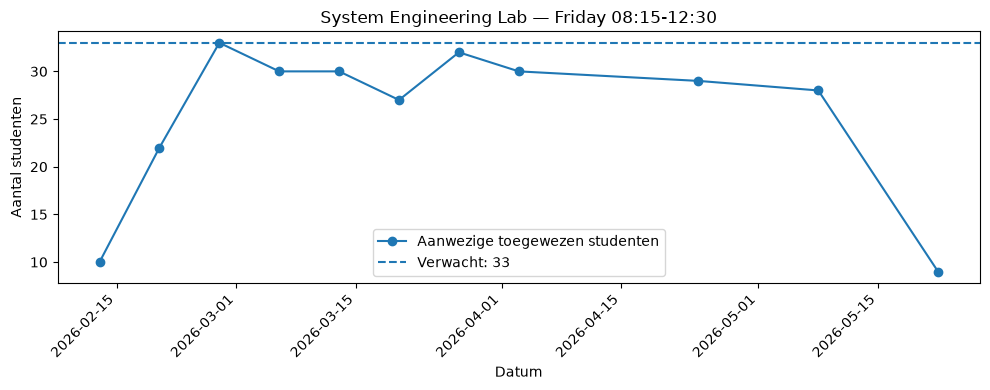

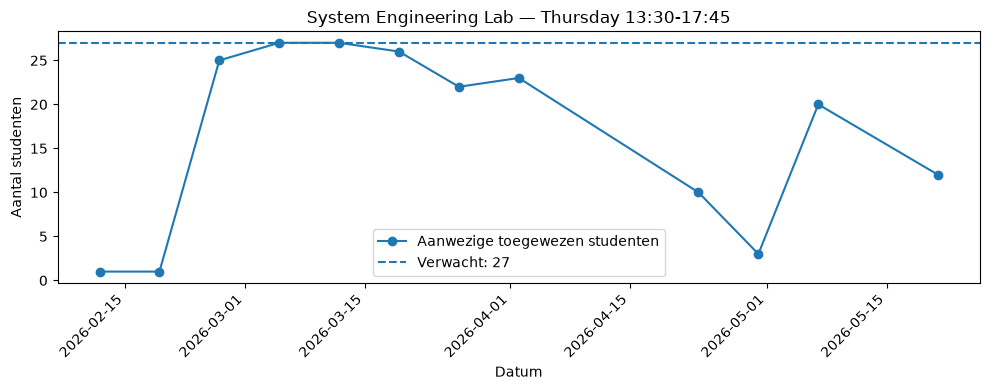

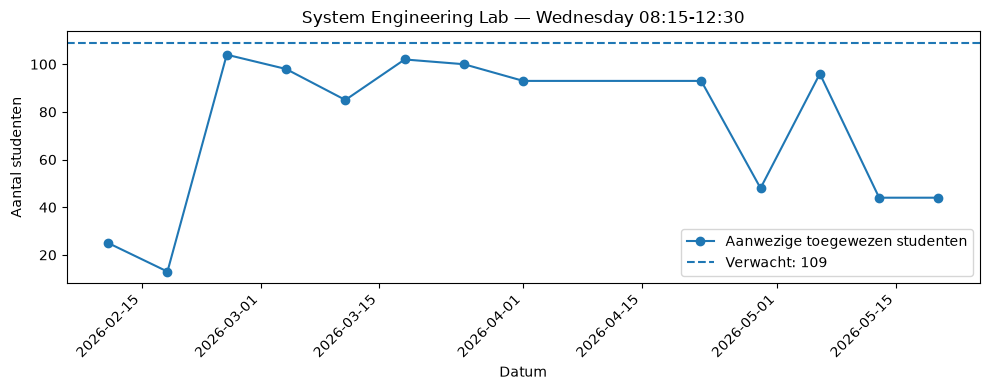

In [18]:
for session_slot, group in session_results.groupby("SessionSlot"):
    group = group.sort_values("FullDate")
    expected = group["ExpectedStudents"].iloc[0]

    plt.figure(figsize=(10, 4))
    plt.plot(
        group["FullDate"],
        group["PresentAssignedStudents"],
        marker="o",
        label="Aanwezige toegewezen studenten",
    )
    plt.axhline(
        expected,
        linestyle="--",
        label=f"Verwacht: {expected}",
    )
    plt.xlabel("Datum")
    plt.ylabel("Aantal studenten")
    plt.title(f"System Engineering Lab — {session_slot}")
    plt.xticks(rotation=45, ha="right")
    plt.legend()
    plt.tight_layout()
    plt.show()


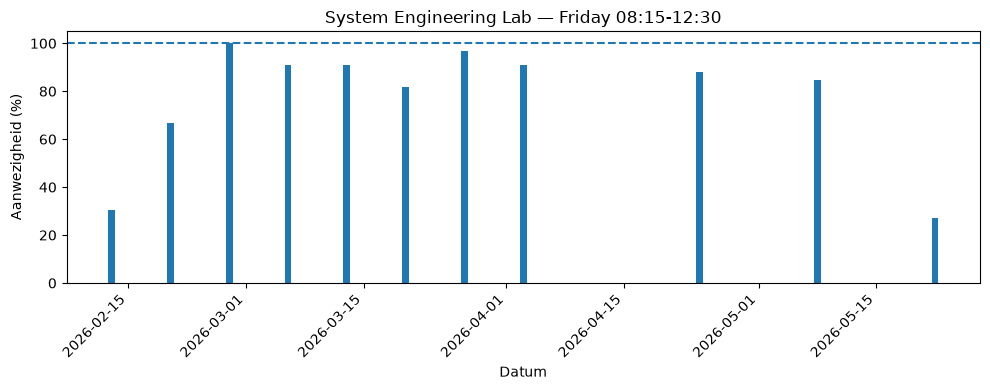

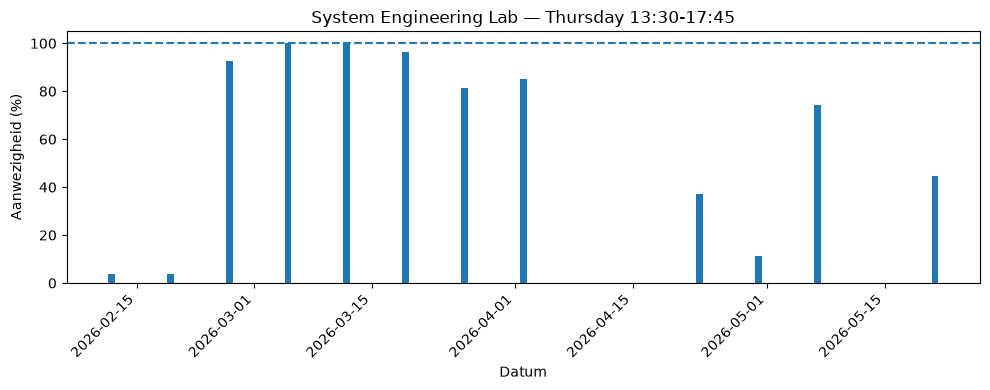

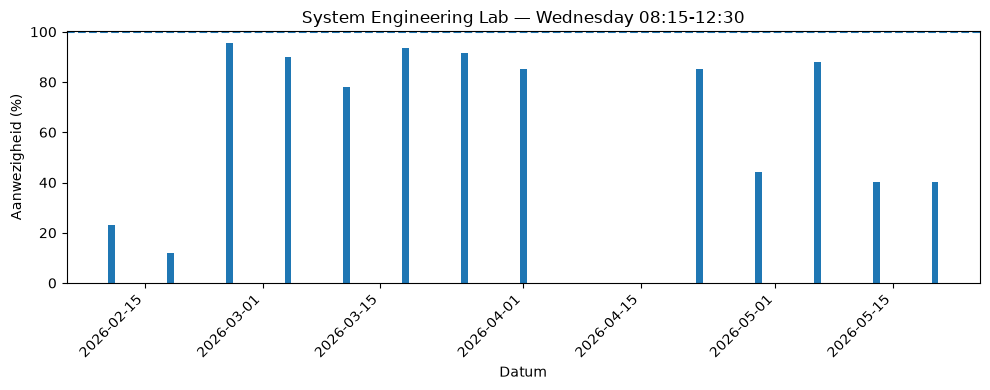

In [19]:
for session_slot, group in session_results.groupby("SessionSlot"):
    group = group.sort_values("FullDate")

    plt.figure(figsize=(10, 4))
    plt.bar(
        group["FullDate"],
        group["AttendanceRate"] * 100,
    )
    plt.axhline(100, linestyle="--")
    plt.xlabel("Datum")
    plt.ylabel("Aanwezigheid (%)")
    plt.title(f"System Engineering Lab — {session_slot}")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


## 16. Privacyveilige exports

In [20]:
session_results.to_csv(
    "system_engineering_lab_wifi_inferred_attendance.csv",
    index=False,
)

inferred_group_sizes.to_csv(
    "system_engineering_lab_inferred_group_sizes.csv",
    index=False,
)

print("Privacyveilige exports aangemaakt.")


Privacyveilige exports aangemaakt.


In [21]:
EXPORT_PRIVATE_ASSIGNMENTS = False

if EXPORT_PRIVATE_ASSIGNMENTS:
    user_assignments.to_csv(
        "system_engineering_lab_user_assignments_PRIVATE.csv",
        index=False,
    )
    print("Privé-export met UserKey aangemaakt.")
else:
    print("Geen privé-export aangemaakt.")


Geen privé-export aangemaakt.


## Interpretatie en beperkingen

De verwachte groepsgrootte wordt nu niet langer afgeleid uit alle administratief gekoppelde subgroepen of uit één maximum.

Iedere gepseudonimiseerde gebruiker wordt toegewezen aan het vaste sessietype waarin die, buiten de eventuele introductieweek, het vaakst via wifi werd waargenomen.

De aanwezigheid per sessie wordt vervolgens:

> toegewezen gebruikers die tijdens die sessie verbonden waren / alle gebruikers die aan dat sessietype zijn toegewezen

Beperkingen:

1. studenten die nooit of nauwelijks wifi gebruiken, kunnen niet betrouwbaar worden toegewezen;
2. zonder access-pointgegevens blijft wifi-connectie een proxy voor aanwezigheid in het juiste lokaal;
3. de methode steunt op de projectaanname dat een verbonden student tijdens zijn geroosterde les aanwezig is;
4. studenten met een gelijkspel of te weinig observaties worden standaard niet toegewezen;
5. structurele groepswissels midden in het semester vragen mogelijk een tijdsafhankelijke toewijzing;
6. `UserName`, naam, e-mail en andere pseudoniemen mogen niet publiek geëxporteerd worden.
